In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
daily_data = pd.read_csv('../data/processed/onion_cleaned.csv', parse_dates=['Arrival_Date'])
daily_data.head()

,Market,Arrival_Date,Commodity_Code,Max_Price,Min_Price,Modal_Price,Rolling_Median,Price_Ratio,Next_Price,Next_Rolling_Median,Next_Price_Ratio,Likely_Error
0,Chandvad,2003-01-30,23.0,155.0,90.0,130.0,NaN,NaN,110.0,NaN,NaN,False
1,Chandvad,2003-02-06,23.0,130.0,60.0,110.0,NaN,NaN,135.0,130.0,1.038462,False
2,Chandvad,2003-02-07,23.0,155.0,60.0,135.0,130.0,1.038462,125.0,127.5,0.980392,False
3,Chandvad,2003-02-13,23.0,207.0,80.0,125.0,127.5,0.980392,130.0,130.0,1.000000,False
4,Chandvad,2003-02-15,23.0,191.0,60.0,130.0,130.0,1.000000,130.0,130.0,1.000000,False


#### **Seasonality check (one market, one year, zoomed in)**

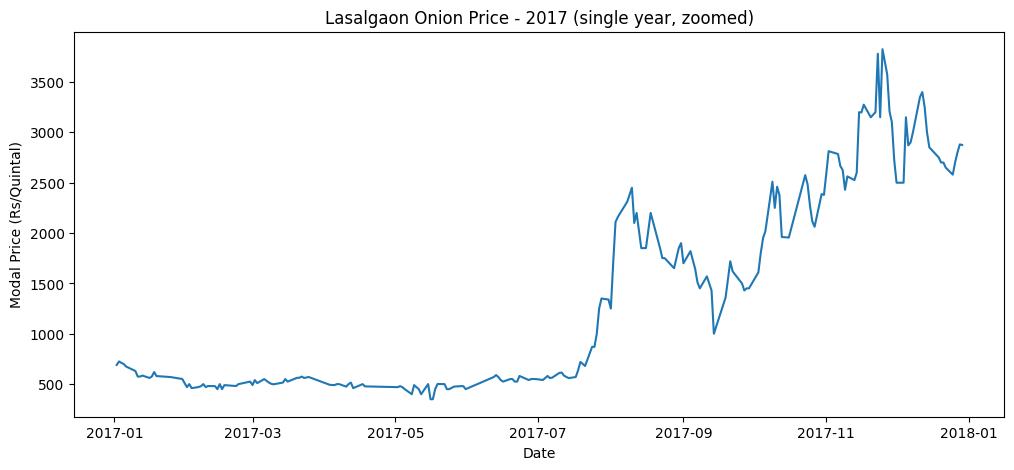

In [5]:
subset = daily_data[(daily_data['Market'] == 'Lasalgaon') & (daily_data['Arrival_Date'].dt.year == 2017)]
subset = subset.sort_values('Arrival_Date')

plt.figure(figsize=(12,5))
plt.plot(subset['Arrival_Date'], subset['Modal_Price'])
plt.title('Lasalgaon Onion Price - 2017 (single year, zoomed)')
plt.xlabel('Date')
plt.ylabel('Modal Price (Rs/Quintal)')
plt.show()

#### **Market correlation matrix (numeric proof of co-movement)**

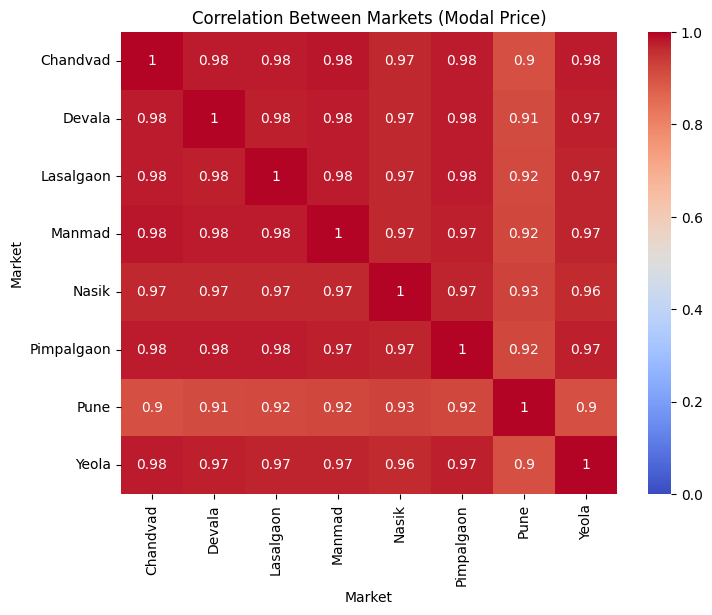

In [6]:
pivot = daily_data.pivot_table(index='Arrival_Date', columns='Market', values='Modal_Price')
corr = pivot.corr()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation Between Markets (Modal Price)')
plt.show()